# 📈 RetailPulse — Time Series Decomposition
## Objective
Decompose the monthly sales time series into Trend, Seasonality, 
and Residual components to understand underlying patterns.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Loading cleaned dataset
df = pd.read_csv('../data/superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print("✅ Libraries imported and data loaded successfully!")
print("Shape:", df.shape)

✅ Libraries imported and data loaded successfully!
Shape: (9994, 24)


## 1. Preparing Monthly Time Series
Grouping sales data by month to create a time series.

In [2]:
# Creating monthly sales time series
monthly_sales = df.groupby('Month_Year')['Sales'].sum()
monthly_sales.index = pd.PeriodIndex(monthly_sales.index, freq='M')
monthly_sales = monthly_sales.sort_index()

# Convert to datetime for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

print("Monthly Sales Time Series:")
print(monthly_sales)

Monthly Sales Time Series:
Month_Year
2014-01-01     14236.8950
2014-02-01      4519.8920
2014-03-01     55691.0090
2014-04-01     28295.3450
2014-05-01     23648.2870
2014-06-01     34595.1276
2014-07-01     33946.3930
2014-08-01     27909.4685
2014-09-01     81777.3508
2014-10-01     31453.3930
2014-11-01     78628.7167
2014-12-01     69545.6205
2015-01-01     18174.0756
2015-02-01     11951.4110
2015-03-01     38726.2520
2015-04-01     34195.2085
2015-05-01     30131.6865
2015-06-01     24797.2920
2015-07-01     28765.3250
2015-08-01     36898.3322
2015-09-01     64595.9180
2015-10-01     31404.9235
2015-11-01     75972.5635
2015-12-01     74919.5212
2016-01-01     18542.4910
2016-02-01     22978.8150
2016-03-01     51715.8750
2016-04-01     38750.0390
2016-05-01     56987.7280
2016-06-01     40344.5340
2016-07-01     39261.9630
2016-08-01     31115.3743
2016-09-01     73410.0249
2016-10-01     59687.7450
2016-11-01     79411.9658
2016-12-01     96999.0430
2017-01-01     43971.3740


## 2. Additive Decomposition
Decomposing the time series into Trend, Seasonality, and Residual 
using Additive model (used when seasonality is constant over time).

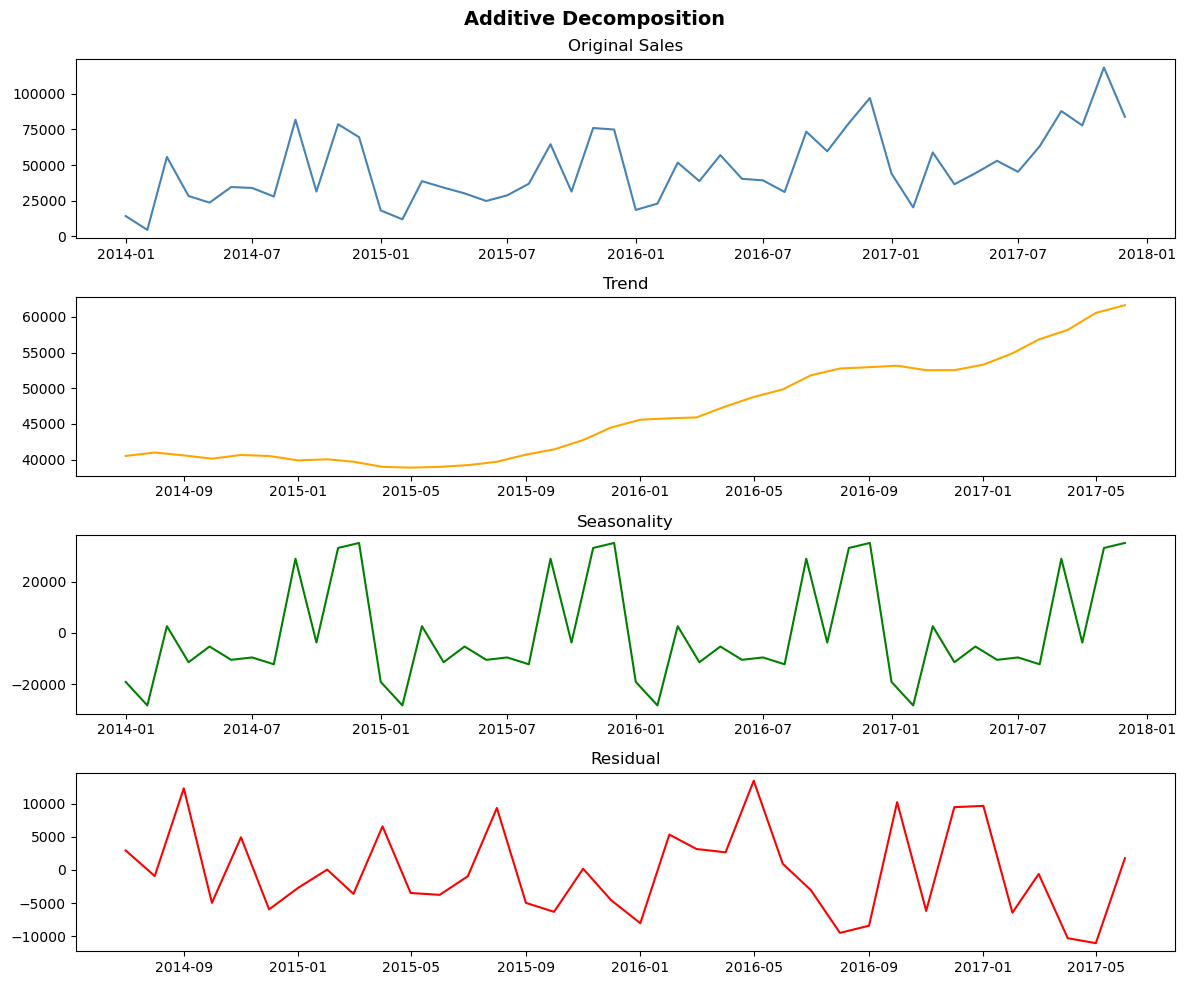

In [3]:
# Additive Decomposition
result_add = seasonal_decompose(monthly_sales, model='additive', period=12)

# Plotting manually
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(monthly_sales, color='steelblue')
axes[0].set_title('Original Sales')

axes[1].plot(result_add.trend, color='orange')
axes[1].set_title('Trend')

axes[2].plot(result_add.seasonal, color='green')
axes[2].set_title('Seasonality')

axes[3].plot(result_add.resid, color='red')
axes[3].set_title('Residual')

plt.suptitle('Additive Decomposition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Multiplicative Decomposition
Decomposing using Multiplicative model 
(used when seasonality increases with trend).

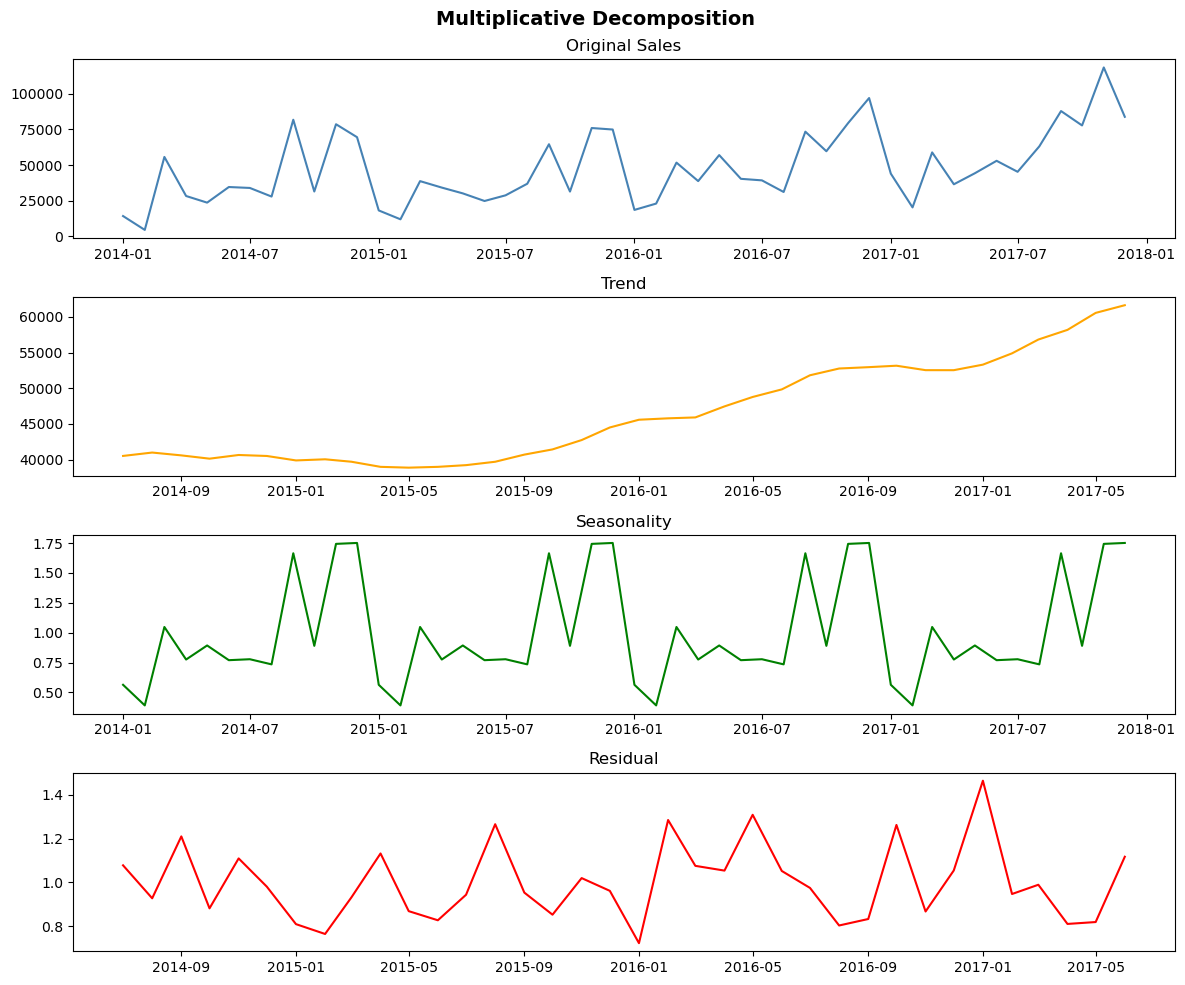

In [4]:
# Multiplicative Decomposition
result_mul = seasonal_decompose(monthly_sales, model='multiplicative', period=12)

# Plotting manually
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(monthly_sales, color='steelblue')
axes[0].set_title('Original Sales')

axes[1].plot(result_mul.trend, color='orange')
axes[1].set_title('Trend')

axes[2].plot(result_mul.seasonal, color='green')
axes[2].set_title('Seasonality')

axes[3].plot(result_mul.resid, color='red')
axes[3].set_title('Residual')

plt.suptitle('Multiplicative Decomposition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Key Observations
Summary of findings from decomposition analysis.

In [5]:
print("Key Observations from Decomposition:")
print("=" * 45)
print("1. Strong upward trend from 2014 to 2017")
print("2. Clear seasonality — sales peak every Sep-Nov")
print("3. Sales dip every Jan-Feb (post-holiday slowdown)")
print("4. Multiplicative model fits better as seasonality grows with trend")
print("5. Residuals are small — trend & seasonality explain data well")

Key Observations from Decomposition:
1. Strong upward trend from 2014 to 2017
2. Clear seasonality — sales peak every Sep-Nov
3. Sales dip every Jan-Feb (post-holiday slowdown)
4. Multiplicative model fits better as seasonality grows with trend
5. Residuals are small — trend & seasonality explain data well
